# Titanic Visual Story

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

# Consistent style across all charts
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12

SURVIVED_COLORS = {'Did Not Survive': '#d9534f', 'Survived': '#5cb85c'}
CLASS_COLORS    = ['#2196F3', '#FF9800', '#F44336']

## Data — Load and Clean

In [3]:
# Load dataset
df = pd.read_csv('../data/titanic.csv')

# Age: fill missing values using median within Pclass × Sex groups
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

# Fill any remaining Age values with overall median
# (usually only a couple of rows, so chart impact is negligible)
df['Age'] = df['Age'].fillna(df['Age'].median())

# Embarked: fill missing values with most common port
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Cabin: create binary feature and drop original column
df['Has_Cabin'] = df['Cabin'].notna().astype(int)
df.drop(columns=['Cabin'], inplace=True)

# Family Size feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

print(f'Dataset ready: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Missing values: {df.isnull().sum().sum()}')

Dataset ready: 891 rows, 13 columns
Missing values: 0


---
## Chart 1 - Survival Rate by Gender

The opening chart. Gender was the most powerful predictor of survival, driven by the "women and children first" evacuation protocol.

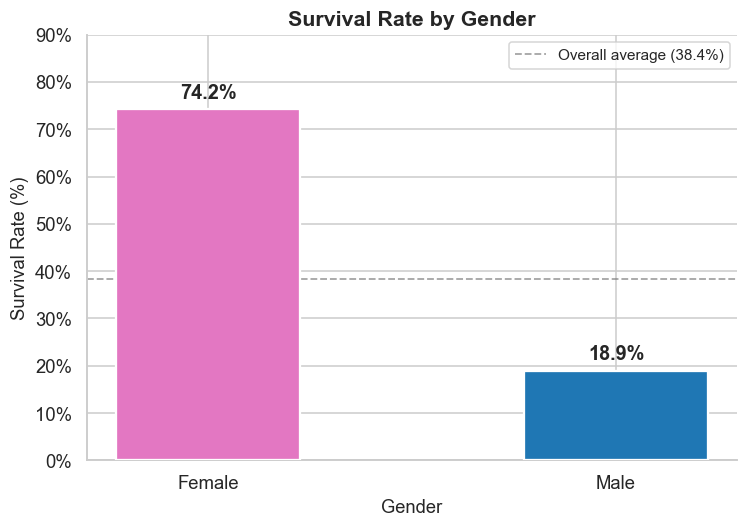

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))

surv_sex = df.groupby('Sex')['Survived'].mean() * 100
gender_labels = ['Female', 'Male']
colors = ['#e377c2', '#1f77b4']

bars = ax.bar(gender_labels, surv_sex[['female', 'male']].values,
              color=colors, edgecolor='white', linewidth=1.5, width=0.45, zorder=3)

for bar, val in zip(bars, surv_sex[['female', 'male']].values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.5,
            f'{val:.1f}%', ha='center', va='bottom',
            fontsize=13, fontweight='bold')

overall = df['Survived'].mean() * 100
ax.axhline(overall, color='grey', linestyle='--', linewidth=1.2, alpha=0.7,
           label=f'Overall average ({overall:.1f}%)')

ax.set_title('Survival Rate by Gender')
ax.set_xlabel('Gender')
ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, 90)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

**Takeaway:** Women survived at 74% - nearly four times the male rate of 19% - making gender the single strongest predictor of survival in the dataset.

---
## Chart 2 - Survival Rate by Class and Gender

Gender alone does not tell the full story. This chart layers in passenger class to show how the two biggest factors combined.

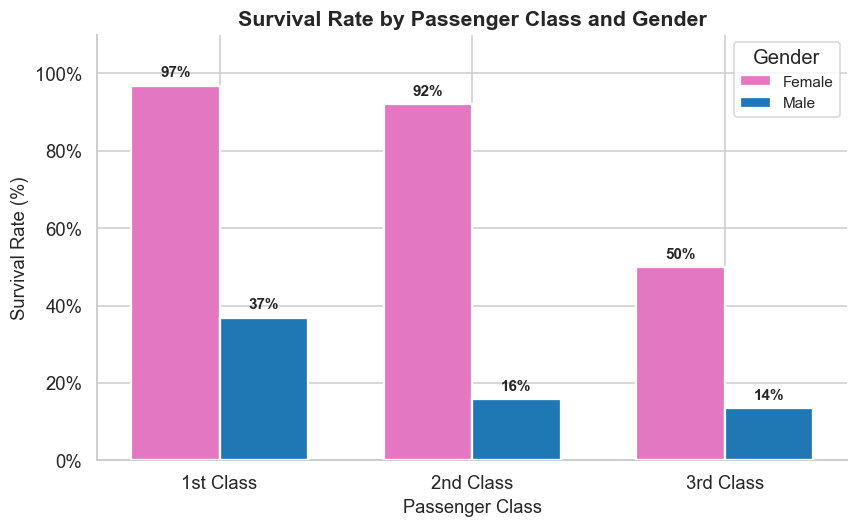

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

pivot = df.pivot_table(values='Survived', index='Pclass',
                       columns='Sex', aggfunc='mean') * 100

x = np.arange(3)
width = 0.35

bars_f = ax.bar(x - width / 2, pivot['female'].values, width,
                label='Female', color='#e377c2', edgecolor='white', linewidth=1.5, zorder=3)
bars_m = ax.bar(x + width / 2, pivot['male'].values, width,
                label='Male', color='#1f77b4', edgecolor='white', linewidth=1.5, zorder=3)

for bars in [bars_f, bars_m]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1.5,
                f'{bar.get_height():.0f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Survival Rate by Passenger Class and Gender')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Survival Rate (%)')
ax.set_xticks(x)
ax.set_xticklabels(['1st Class', '2nd Class', '3rd Class'])
ax.set_ylim(0, 110)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title='Gender', fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

**Takeaway:** Even 3rd-class women (50%) outlived every male group - but 3rd-class men had the worst odds of all at just 15%, showing that class and gender compounded against them.

---
## Chart 3 - Age Distribution by Survival

After class and gender, age is the next factor to examine. Were children really prioritised?

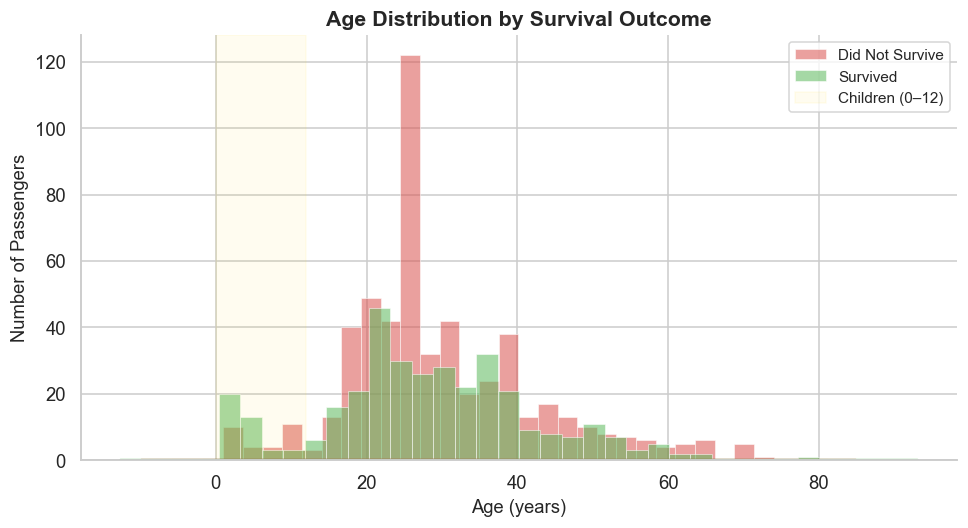

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

for survived, label, color in [
    (0, 'Did Not Survive', '#d9534f'),
    (1, 'Survived',        '#5cb85c')
]:
    subset = df[df['Survived'] == survived]['Age']
    ax.hist(subset, bins=28, alpha=0.55, label=label,
            color=color, edgecolor='white', linewidth=0.6)
    sns.kdeplot(subset, ax=ax, color=color, linewidth=2)

ax.axvspan(0, 12, alpha=0.06, color='gold', label='Children (0–12)')

ax.set_title('Age Distribution by Survival Outcome')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Number of Passengers')
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

**Takeaway:** Children under 12 (shaded region) are proportionally more represented among survivors, while the large peak of non-survivors in the 20–35 range reflects the heavy losses among young men in 3rd class.

---
## Chart 4 - Fare Distribution by Survival

Fare is a continuous measure of wealth. A violin plot shows both the median and the full shape of the distribution - more informative than a boxplot alone.

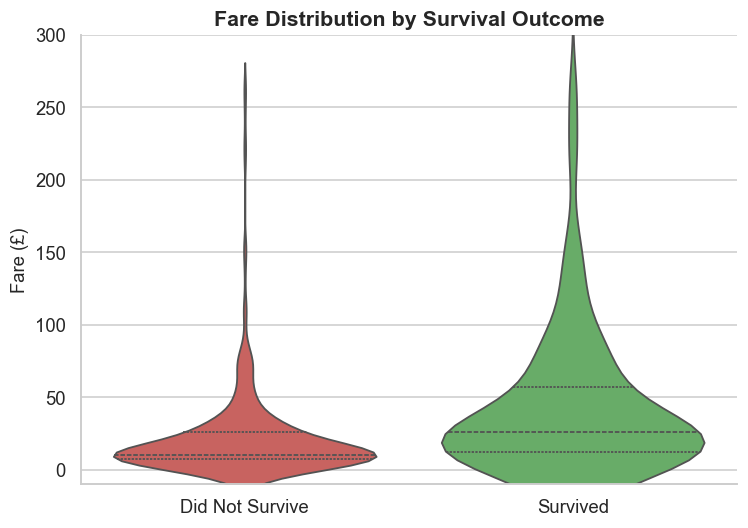

Median fare — Did Not Survive: £10.50
Median fare — Survived: £26.00


In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

df['Survival Label'] = df['Survived'].map({0: 'Did Not Survive', 1: 'Survived'})

sns.violinplot(
    x='Survival Label', y='Fare', data=df,
    palette=['#d9534f', '#5cb85c'],
    inner='quartile',
    linewidth=1.2,
    ax=ax
)

ax.set_title('Fare Distribution by Survival Outcome')
ax.set_xlabel('')
ax.set_ylabel('Fare (£)')
ax.set_ylim(-10, 300)
sns.despine()
plt.tight_layout()
plt.show()

for label, val in df.groupby('Survival Label')['Fare'].median().items():
    print(f'Median fare — {label}: £{val:.2f}')

**Takeaway:** Survivors paid a median fare of ~£26 versus ~£11 for non-survivors - and their distribution skews substantially higher, confirming that wealth bought better odds of survival.

---
## Chart 5 - Survival Rate Heatmap: Class × Gender

This single chart shows every class-gender subgroup at once. It is the clearest way to communicate how the two dominant factors interacted.

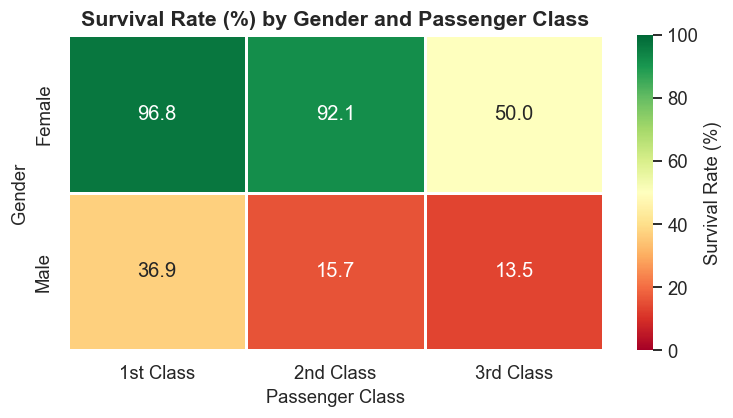

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))

pivot_hm = df.pivot_table(
    values='Survived', index='Sex', columns='Pclass', aggfunc='mean'
) * 100

pivot_hm.index = ['Female', 'Male']
pivot_hm.columns = ['1st Class', '2nd Class', '3rd Class']

sns.heatmap(
    pivot_hm,
    annot=True, fmt='.1f',
    cmap='RdYlGn',
    vmin=0, vmax=100,
    linewidths=0.8,
    cbar_kws={'label': 'Survival Rate (%)'},
    ax=ax
)

ax.set_title('Survival Rate (%) by Gender and Passenger Class')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Gender')
plt.tight_layout()
plt.show()

**Takeaway:** The heatmap makes the privilege gradient impossible to miss - 1st-class women survived at 97%, while 3rd-class men survived at just 15%, a gap of 82 percentage points across the same ship.

---
## Chart 6 - Family Size vs Survival

This analysis was not in Lesson 1. Family size (SibSp + Parch + 1) explores whether travelling with others helped or hindered survival.

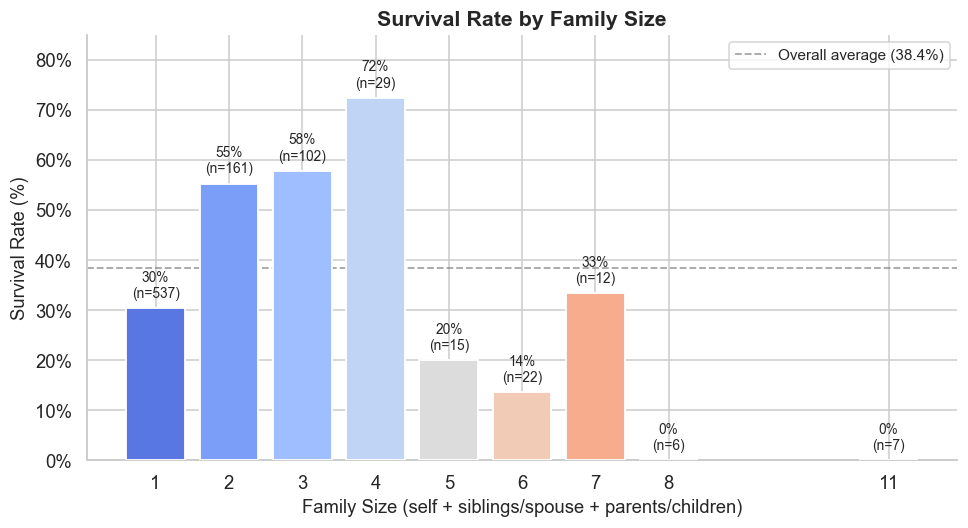

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

fam_surv = df.groupby('FamilySize').agg(
    SurvivalRate=('Survived', 'mean'),
    Count=('Survived', 'count')
).reset_index()
fam_surv['SurvivalRate'] *= 100

bars = ax.bar(
    fam_surv['FamilySize'], fam_surv['SurvivalRate'],
    color=sns.color_palette('coolwarm', len(fam_surv)),
    edgecolor='white', linewidth=1.2, zorder=3
)

for bar, row in zip(bars, fam_surv.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f'{row.SurvivalRate:.0f}%\n(n={row.Count})',
        ha='center', va='bottom', fontsize=9
    )

ax.axhline(df['Survived'].mean() * 100, color='grey',
           linestyle='--', linewidth=1.2, alpha=0.7,
           label=f'Overall average ({df["Survived"].mean()*100:.1f}%)')

ax.set_title('Survival Rate by Family Size')
ax.set_xlabel('Family Size (self + siblings/spouse + parents/children)')
ax.set_ylabel('Survival Rate (%)')
ax.set_xticks(fam_surv['FamilySize'])
ax.set_ylim(0, 85)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

**Takeaway:** Small families of 2-4 survived at the highest rates (~55-72%), while solo travellers and very large families (7+) fared worst - suggesting that a small group helped each other to safety, but coordinating a large family in a crisis proved fatal.

---
## Summary

The six charts above tell a single, coherent story about who survived the Titanic and why.

Gender was the dominant factor. Women survived at 74% compared to just 19% of men - a gap driven almost entirely by the "women and children first" boarding protocol enforced by the crew. This alone explains more of the survival difference than any other variable.

Passenger class came second and compounded the gender effect. First-class passengers survived at 63%, second-class at 47%, and third-class at only 24%. The heatmap makes this vivid: a 1st-class woman survived at 97%, a 3rd-class man at 15% - on the same ship, on the same night. Physical cabin location mattered: upper-deck cabins were closer to lifeboats, and wealthier passengers had better information and less distance to cover.

Fare reinforces the class finding from a different angle. Survivors paid a median of £26 versus £11 for non-survivors, with the survivor distribution skewing noticeably higher.

Age added a smaller but visible signal. Children under 12 were proportionally more likely to survive, while the 20–35 male peak dominates the non-survivor histogram - a direct reflection of the many young men in 3rd class.

Finally, family size revealed a nuanced pattern not visible in lesson 1: travelling in a small group of 2–4 was a survival advantage, while being alone or part of a very large family was not.

In short: survival on the Titanic was structured, not random. Gender, class, and wealth determined who reached the lifeboats.